In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import tqdm

from flab.empirics import ExptTrace, rcsetup
rcsetup(panel_color='parchment')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32
torch.set_float32_matmul_precision('medium')
RNG    = torch.Generator(device=DEVICE).manual_seed(42)
print(f'device={DEVICE}  dtype={DTYPE}')

def reseed(seed: int) -> None:
    global RNG
    RNG = torch.Generator(device=DEVICE).manual_seed(seed)

device=cuda  dtype=torch.float32


In [2]:
# == TARGET, LOSS ===========================================================

reseed(0)
N        = 32
EXPONENT = 1.0

def make_target(n: int, exponent: float) -> torch.Tensor:
    offset = 1
    sv = 10 * torch.arange(offset, n + offset, dtype=torch.float64) ** (-exponent)
    print(sv)
    return torch.diag(sv).to(dtype=DTYPE, device=DEVICE)

M_STAR = make_target(N, EXPONENT)

@torch.compile
def _loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return 0.5 * (pred - target).pow(2).sum()

tensor([10.0000,  5.0000,  3.3333,  2.5000,  2.0000,  1.6667,  1.4286,  1.2500,
         1.1111,  1.0000,  0.9091,  0.8333,  0.7692,  0.7143,  0.6667,  0.6250,
         0.5882,  0.5556,  0.5263,  0.5000,  0.4762,  0.4545,  0.4348,  0.4167,
         0.4000,  0.3846,  0.3704,  0.3571,  0.3448,  0.3333,  0.3226,  0.3125],
       dtype=torch.float64)


# Experiment

In [3]:
import torch.optim as optim

class Muon(optim.Optimizer):

    def __init__(self, params, lr: float = 0.01, ns_steps: int = 5):
        defaults = dict(lr=lr, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.compile
    def _polar(G: torch.Tensor) -> torch.Tensor:
        U, _, Vh = torch.linalg.svd(G, full_matrices=False)
        return U @ Vh

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                G = p.grad
                if G.ndim < 2:
                    update = G / (G.norm() + 1e-7)
                else:
                    update = Muon._polar(G)
                p.add_(update, alpha=-lr)

In [4]:
# EXPERIMENT 1

sv = ExptTrace(["opt", "iter"])
reseed(64)
alpha = 5e-3
d = N
num_steps = 1000

lr = 5e-3
sv_target = M_STAR.diagonal().cpu().numpy()

for opt_name in ["muon", "sgd"]:
    W1 = torch.nn.Parameter(
        torch.randn(d, N, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)
    W2 = torch.nn.Parameter(
        torch.randn(N, d, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)

    if opt_name == "sgd":
        opt = optim.SGD([W1, W2], lr=3*lr)
    elif opt_name == "muon":
        opt = Muon([W1, W2], lr=lr)

    for t in range(num_steps):
        with torch.no_grad():
            svals = torch.linalg.svdvals(W2).detach().cpu().numpy()
            sv[opt_name, t] = svals
        opt.zero_grad()
        loss = _loss(W2 @ W1, M_STAR)
        loss.backward()
        opt.step()

with open(f'fig1_sv.pkl', 'wb') as f:
    pickle.dump(sv.serialize(), f)

In [5]:
# EXPERIMENT 2

losses = ExptTrace(["opt", "iter", "lr"])
reseed(64)
alpha = 1e-1
d = N

lr_max = .14
lrs = np.logspace(np.log10(5e-2*lr_max), np.log10(20*lr_max), num=200, base=10)
sv_target = M_STAR.diagonal().cpu().numpy()
loss_init = 0.5 * (M_STAR.pow(2).sum().item())

for opt_name in ["muon", "sgd"]:
    for lr in tqdm.tqdm(lrs):
        W1 = torch.nn.Parameter(
            torch.randn(d, N, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)
        W2 = torch.nn.Parameter(
            torch.randn(N, d, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)

        if opt_name == "sgd":
            opt = optim.SGD([W1, W2], lr=lr)
        elif opt_name == "muon":
            opt = Muon([W1, W2], lr=lr)
        prev_loss = 0
        num_steps = 500 if opt_name == "muon" else 2000
        for t in range(num_steps):
            opt.zero_grad()
            loss = _loss(W2 @ W1, M_STAR)
            losses[opt_name, t, lr] = 0.5*(loss.item() + prev_loss) / loss_init
            prev_loss = loss.item()
            loss.backward()
            opt.step()

with open(f'fig1_losses.pkl', 'wb') as f:
    pickle.dump(losses.serialize(), f)

100%|██████████| 200/200 [03:16<00:00,  1.02it/s]


In [6]:
# EXPERIMENT 3

@torch.compile
def get_deltas(W1, W2):
    
    def matrix_sqrt(A):
        L, V = torch.linalg.eigh(A)
        return V @ torch.diag(L.clamp(min=0.0).sqrt()) @ V.mT
    
    with torch.no_grad():
        A = W2.mT @ W2
        B = W1 @ W1.mT
        delta1 = (matrix_sqrt(A) - matrix_sqrt(B)).detach().cpu().numpy()
        delta2 = (A - B).detach().cpu().numpy()
    return delta1, delta2

deltas = ExptTrace(["opt", "quantity", "iter"])

reseed(64)
alpha = 5e-3
d = N
num_steps = 1200

lr = 5e-4
sv_target = M_STAR.diagonal().cpu().numpy()

for opt_name in ["muon", "sgd"]:
    W1 = torch.nn.Parameter(
        torch.randn(d, N, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)
    W2 = torch.nn.Parameter(
        torch.randn(N, d, generator=RNG, dtype=DTYPE, device=DEVICE) * alpha)

    if opt_name == "sgd":
        opt = optim.SGD([W1, W2], lr=5*lr)
    elif opt_name == "muon":
        opt = Muon([W1, W2], lr=lr)

    for t in range(num_steps):
        delta1, delta2 = get_deltas(W1, W2)
        deltas[opt_name, "delta1", t] = delta1
        deltas[opt_name, "delta2", t] = delta2
        opt.zero_grad()
        loss = _loss(W2 @ W1, M_STAR)
        loss.backward()
        opt.step()
with open(f'fig1_conservation.pkl', 'wb') as f:
    pickle.dump(deltas.serialize(), f)

# Plotting

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


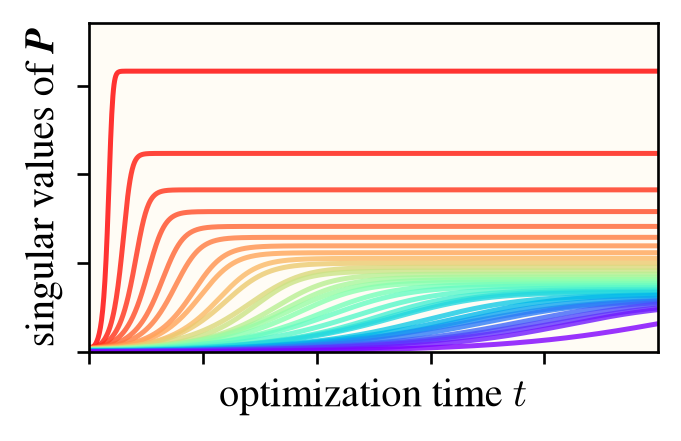

In [7]:
with open(f'fig1_sv.pkl', 'rb') as f:
    sv = ExptTrace.deserialize(pickle.load(f))
    
fig, ax = plt.subplots(figsize=(3, 2))
cmap = plt.cm.rainbow
colors = [cmap(k / (N - 1)) for k in range(N)][::-1]

sv_curve = sv["sgd", :].squeeze()
tt = sv.get_axis("iter")[:len(sv_curve)]
for k in range(N):
    ax.plot(tt, sv_curve[:, k], color=colors[k], lw=1.5, alpha=0.8)

ax.set_xlabel(f'optimization time $t$')
ax.set_ylabel(f'singular values of $\\boldsymbol{{P}}$')
ax.set_xlim(0, tt[-1])
ax.set_ylim(0, 3.7)
ax.tick_params(axis='x', labelsize=9, labelbottom=False)
ax.tick_params(axis='y', labelsize=9, labelleft=False)

plt.tight_layout()
plt.savefig('plots/fig1a.pdf', bbox_inches='tight')
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


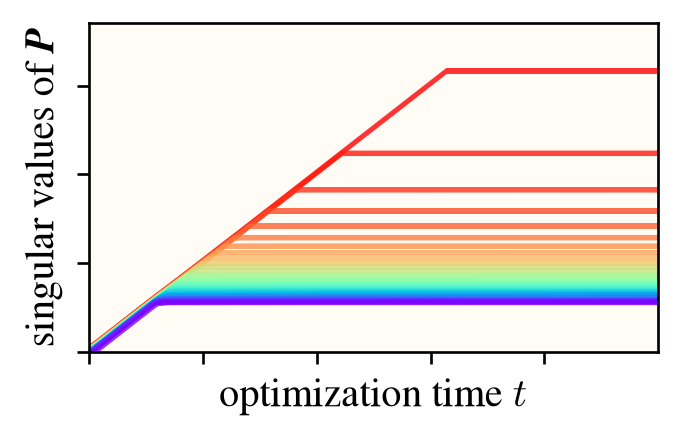

In [8]:
with open(f'fig1_sv.pkl', 'rb') as f:
    sv = ExptTrace.deserialize(pickle.load(f))
    
fig, ax = plt.subplots(figsize=(3, 2))
cmap = plt.cm.rainbow
colors = [cmap(k / (N - 1)) for k in range(N)][::-1]

sv_curve = sv["muon", :].squeeze()
tt = sv.get_axis("iter")[:len(sv_curve)]
for k in range(N):
    ax.plot(tt, sv_curve[:, k], color=colors[k], lw=1.5, alpha=0.8)

ax.set_xlabel(f'optimization time $t$')
ax.set_ylabel(f'singular values of $\\boldsymbol{{P}}$')
ax.set_xlim(0, tt[-1])
ax.set_ylim(0, 3.7)
ax.tick_params(axis='x', labelsize=9, labelbottom=False)
ax.tick_params(axis='y', labelsize=9, labelleft=False)

plt.tight_layout()
plt.savefig('plots/fig1b.pdf', bbox_inches='tight')
plt.show()

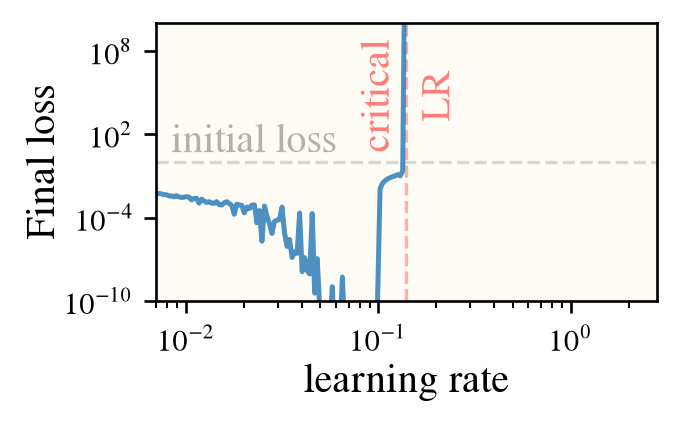

In [9]:
with open(f'fig1_losses.pkl', 'rb') as f:
    losses = ExptTrace.deserialize(pickle.load(f))

fig, ax = plt.subplots(figsize=(3, 2))

lr = losses.get_axis("lr")
final_loss = losses["sgd", 499, :].squeeze()
final_loss = np.nan_to_num(final_loss, nan=1e18)

ax.plot(lr, final_loss, lw=1.5, alpha=0.8)
lr_max = .14
ax.axvline(lr_max, color='red', lw=1.0, ls='--', alpha=0.3, zorder=-5)
ax.text(1.03*lr_max, 5, 'critical\nLR', color='red', fontsize=12, alpha=0.5,
        rotation=90, va='bottom', ha='center')
ax.axhline(1, color='gray', lw=1.0, ls='--', alpha=0.3, zorder=-5)
ax.text(lr[0]*1.2, 1, 'initial loss', color='gray', fontsize=12, alpha=0.6,
        va='bottom', ha='left')

ax.set_xlabel('learning rate', labelpad=1)
ax.set_ylabel('Final loss', labelpad=0)
plt.xlim(lr[0], lr[-1])
plt.ylim(1e-10, 1e10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('plots/fig1c.pdf', bbox_inches='tight')
plt.show()


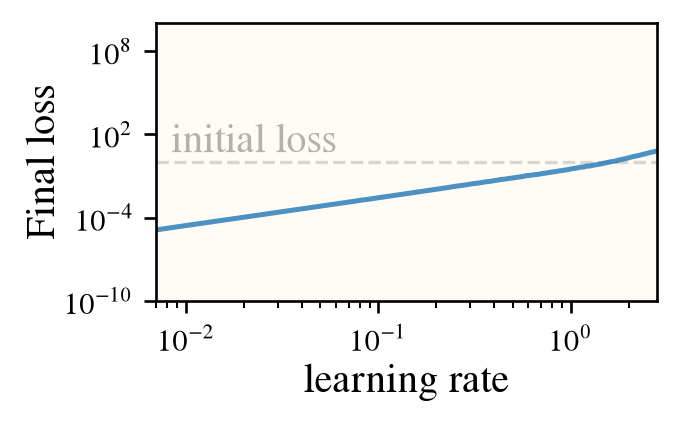

In [10]:
with open(f'fig1_losses.pkl', 'rb') as f:
    losses = ExptTrace.deserialize(pickle.load(f))

fig, ax = plt.subplots(figsize=(3, 2))

lr = losses.get_axis("lr")
final_loss = losses["muon", 499, :].squeeze()
final_loss = np.nan_to_num(final_loss, nan=1e18)

ax.plot(lr, final_loss, lw=1.5, alpha=0.8)
lr_max = .14
# ax.axvline(lr_max, color='red', lw=1.0, ls='--', alpha=0.3, zorder=-5)
# ax.text(1.03*lr_max, 1, 'critical\nLR (GD)', color='red', fontsize=11, alpha=0.5,
        # rotation=90, va='bottom', ha='center')
ax.axhline(1, color='gray', lw=1.0, ls='--', alpha=0.3, zorder=-5)
ax.text(lr[0]*1.2, 1, 'initial loss', color='gray', fontsize=12, alpha=0.6,
        va='bottom', ha='left')

ax.set_xlabel('learning rate', labelpad=1)
ax.set_ylabel('Final loss', labelpad=0)
plt.xlim(lr[0], lr[-1])
plt.ylim(1e-10, 1e10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('plots/fig1d.pdf', bbox_inches='tight')
plt.show()


/tmp/ipykernel_1212097/2368255493.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['' for _ in ax.get_xticks()])
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


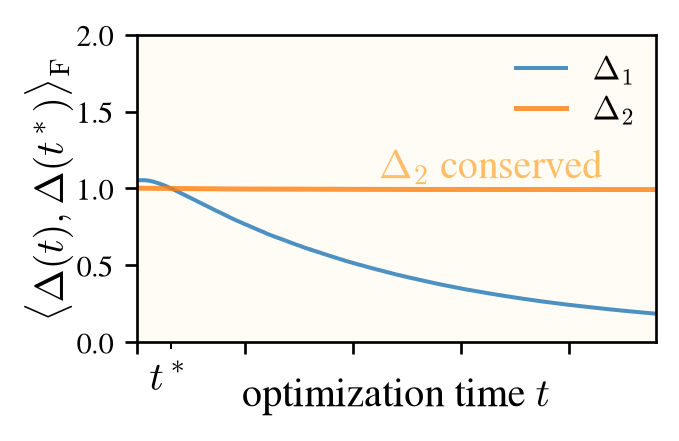

In [11]:
with open(f'fig1_conservation.pkl', 'rb') as f:
    deltas = ExptTrace.deserialize(pickle.load(f))

fig, ax = plt.subplots(figsize=(3, 2))

delta1 = deltas["sgd", "delta1", :].squeeze()
delta2 = deltas["sgd", "delta2", :].squeeze()

tstar = 80
delta1_tstar = delta1[tstar] / np.linalg.norm(delta1[tstar])**2
delta2_tstar = delta2[tstar] / np.linalg.norm(delta2[tstar])**2
overlaps_1 = np.einsum('tij,ij->t', delta1, delta1_tstar)
overlaps_2 = np.einsum('tij,ij->t', delta2, delta2_tstar)
tt = deltas.get_axis("iter")

ax.plot(tt, overlaps_1, lw=1.2, alpha=0.8,
        label=f'$\\Delta_1$')
ax.plot(tt, overlaps_2, lw=1.5, alpha=0.8,
        label=f'$\\Delta_2$')
ax.text(tstar*7, 1, f'$\\Delta_2$ conserved', color='xkcd:tangerine', fontsize=12, alpha=0.6,
        va='bottom', ha='left')
ax.legend(fontsize=10, loc='upper right', framealpha=0.5,
          handlelength=1.5, frameon=False, labelspacing=0.2,
          borderaxespad=0.2)

ax.set_xlabel(f'optimization time $t$', labelpad=-7)
ax.set_ylabel(f"$\\langle\\Delta(t), \\Delta(t^{{\\!\\ast}}) \\rangle_\\mathrm{{F}}$",
              labelpad=1)
ax.set_xlim(0, tt[-1])
ax.set_ylim(0, 2)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.set_xticklabels(['' for _ in ax.get_xticks()])
ax.set_xticks([tstar], minor=True)
ax.set_xticklabels([f"$t^{{\\!\\ast}}$"], minor=True)

plt.tight_layout()
plt.savefig('plots/fig1e.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_1212097/2034683980.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['' for _ in ax.get_xticks()])
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


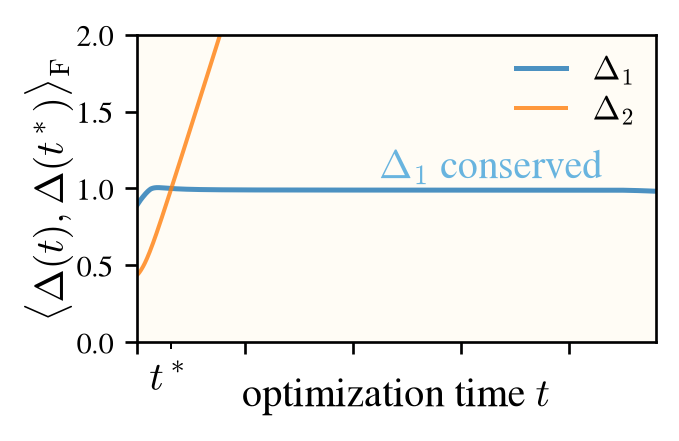

In [12]:
with open(f'fig1_conservation.pkl', 'rb') as f:
    deltas = ExptTrace.deserialize(pickle.load(f))

fig, ax = plt.subplots(figsize=(3, 2))

delta1 = deltas["muon", "delta1", :].squeeze()
delta2 = deltas["muon", "delta2", :].squeeze()

tstar = 80
delta1_tstar = delta1[tstar] / np.linalg.norm(delta1[tstar])**2
delta2_tstar = delta2[tstar] / np.linalg.norm(delta2[tstar])**2
overlaps_1 = np.einsum('tij,ij->t', delta1, delta1_tstar)
overlaps_2 = np.einsum('tij,ij->t', delta2, delta2_tstar)
tt = deltas.get_axis("iter")

ax.plot(tt, overlaps_1, lw=1.5, alpha=0.8,
        label=f'$\\Delta_1$')
ax.plot(tt, overlaps_2, lw=1.2, alpha=0.8,
        label=f'$\\Delta_2$')
ax.text(tstar*7, 1, f'$\\Delta_1$ conserved', color='xkcd:cerulean', fontsize=12, alpha=0.6,
        va='bottom', ha='left')
ax.legend(fontsize=10, loc='upper right', framealpha=0.5,
          handlelength=1.5, frameon=False, labelspacing=0.2,
          borderaxespad=0.2)

ax.set_xlabel(f'optimization time $t$', labelpad=-7)
ax.set_ylabel(f"$\\langle\\Delta(t), \\Delta(t^{{\\!\\ast}}) \\rangle_\\mathrm{{F}}$",
              labelpad=1)
ax.set_xlim(0, tt[-1])
ax.set_ylim(0, 2)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=9)
ax.set_xticklabels(['' for _ in ax.get_xticks()])
ax.set_xticks([tstar], minor=True)
ax.set_xticklabels([f"$t^{{\\!\\ast}}$"], minor=True)

plt.tight_layout()
plt.savefig('plots/fig1f.pdf', bbox_inches='tight')
plt.show()